# Лабораторная работа №2

In [108]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

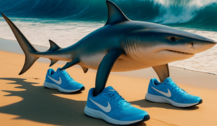

In [109]:
image = Image.open('picture.png')
image

In [110]:
image = np.array(image)
image

array([[[  0,  76, 105, 255],
        [  0,  75, 103, 255],
        [  1,  75, 106, 255],
        ...,
        [186, 195, 188, 255],
        [177, 189, 184, 255],
        [162, 178, 178, 255]],

       [[  0,  77, 107, 255],
        [  1,  76, 107, 255],
        [  2,  75, 105, 255],
        ...,
        [154, 177, 174, 255],
        [155, 177, 175, 255],
        [157, 177, 177, 255]],

       [[  1,  78, 111, 255],
        [  1,  74, 105, 255],
        [  1,  70, 100, 255],
        ...,
        [ 90, 146, 152, 255],
        [114, 160, 164, 255],
        [123, 164, 166, 255]],

       ...,

       [[218, 155,  88, 255],
        [218, 155,  88, 255],
        [217, 154,  88, 255],
        ...,
        [235, 180, 124, 255],
        [235, 181, 124, 255],
        [235, 181, 124, 255]],

       [[217, 155,  88, 255],
        [218, 155,  89, 255],
        [217, 154,  88, 255],
        ...,
        [235, 180, 123, 255],
        [235, 181, 124, 255],
        [234, 180, 123, 255]],

       [[216

In [111]:
R = image[:, :, 0]
G = image[:, :, 1]
B = image[:, :, 2]
R

array([[  0,   0,   1, ..., 186, 177, 162],
       [  0,   1,   2, ..., 154, 155, 157],
       [  1,   1,   1, ...,  90, 114, 123],
       ...,
       [218, 218, 217, ..., 235, 235, 235],
       [217, 218, 217, ..., 235, 235, 234],
       [216, 216, 217, ..., 235, 235, 236]], dtype=uint8)

#  Пространственные области изображения по отдельности и парные комбинации

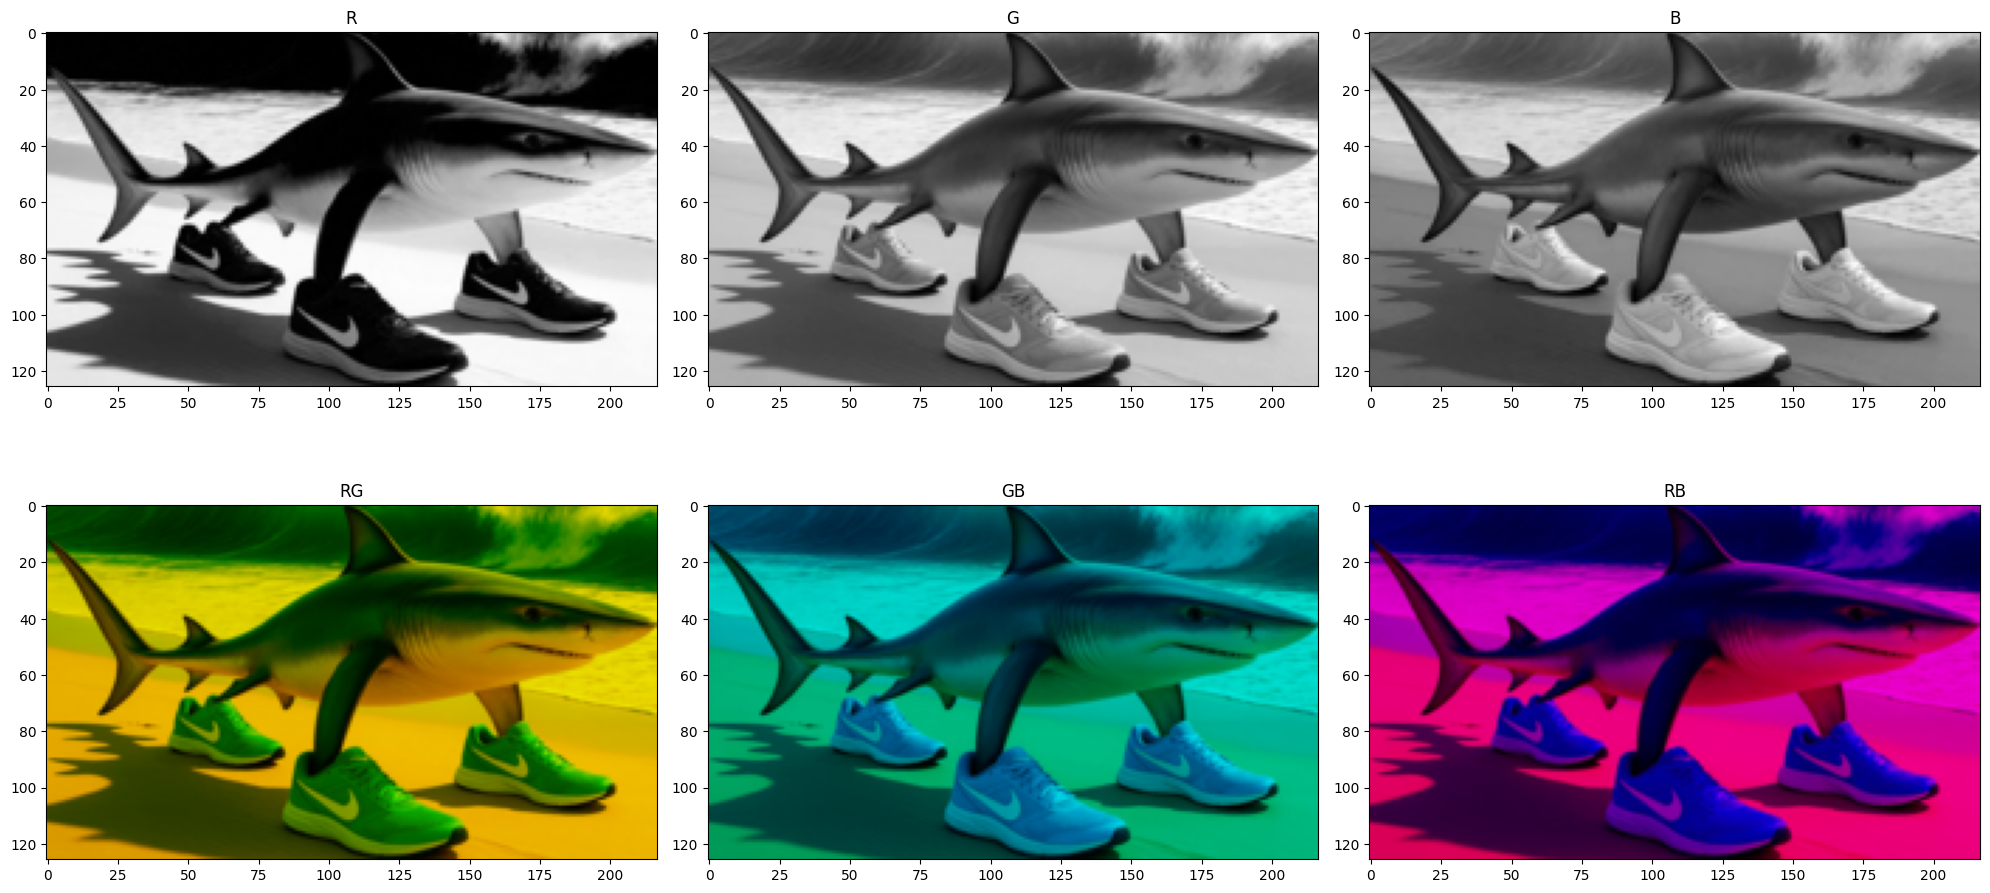

In [113]:
plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
plt.imshow(R, cmap='gray')
plt.title('R')

plt.subplot(2, 3, 2)
plt.imshow(G, cmap='gray')
plt.title('G')

plt.subplot(2, 3, 3)
plt.imshow(B, cmap='gray')
plt.title('B')

# Отображение парных комбинаций
h, w = image.shape[0], image.shape[1]

img_rg = np.zeros((h, w, 3), dtype=np.uint8)
img_rg[:, :, 0] = R
img_rg[:, :, 1] = G

img_gb = np.zeros((h, w, 3), dtype=np.uint8)
img_gb[:, :, 1] = G
img_gb[:, :, 2] = B

img_rb = np.zeros((h, w, 3), dtype=np.uint8)
img_rb[:, :, 0] = R
img_rb[:, :, 2] = B

plt.subplot(2, 3, 4)
plt.imshow(img_rg)
plt.title('RG')

plt.subplot(2, 3, 5)
plt.imshow(img_gb)
plt.title('GB')

plt.subplot(2, 3, 6)
plt.imshow(img_rb)
plt.title('RB')

plt.tight_layout()

# Создание Серого Изображения

#### Человеческий глаз воспринимает цвета по-разному: мы более чувствительны к зеленому свету, чем к красному или синему. Поэтому, чтобы серое изображение выглядело для нас естественно и правильно передавало яркость исходного цвета, используют взвешенное усреднение

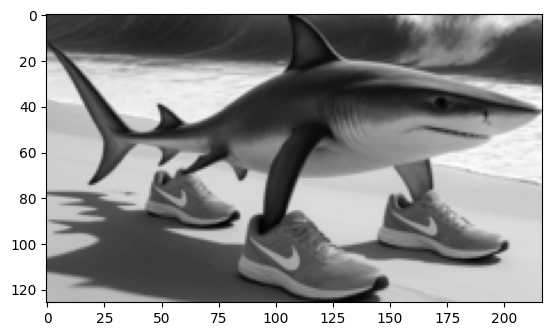

In [114]:
gray_image = (0.2989 * image[:, :, 0] +
                   0.5870 * image[:, :, 1] +
                   0.1140 * image[:, :, 2]).astype(np.uint8)

plt.imshow(gray_image, cmap='gray')

# Графики изменения частоты каналов

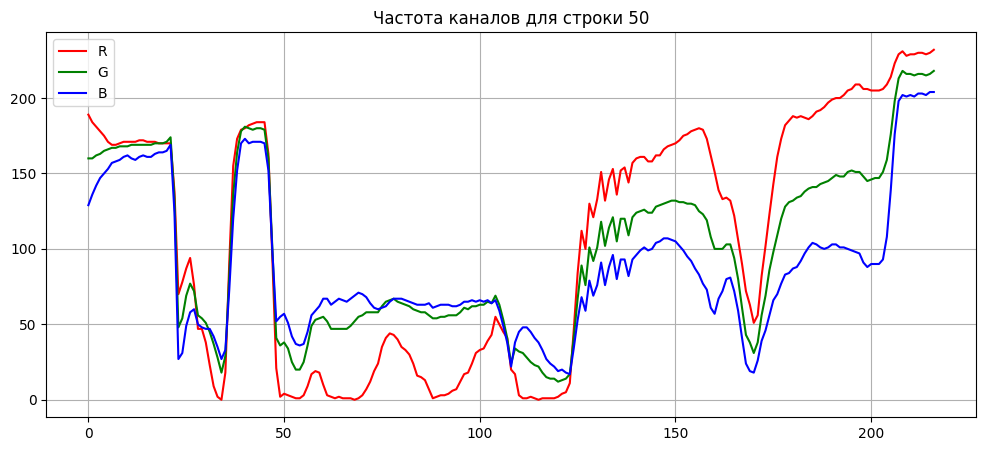

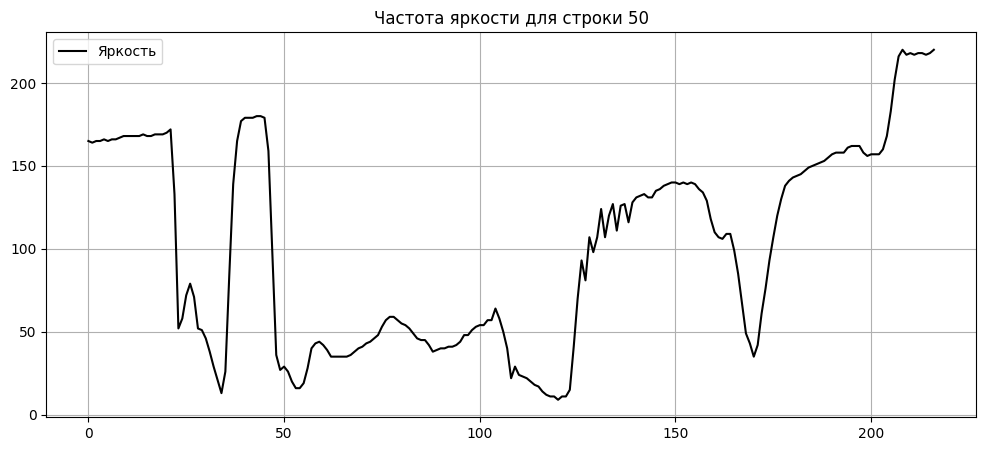

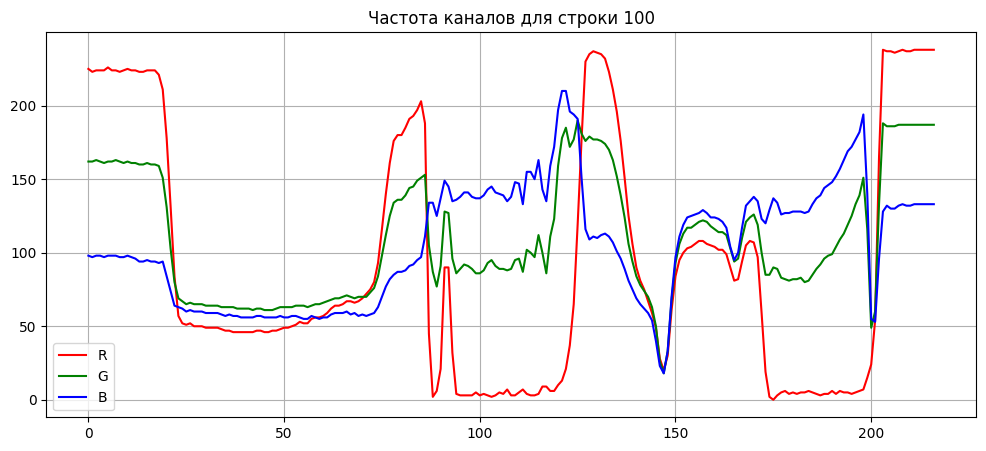

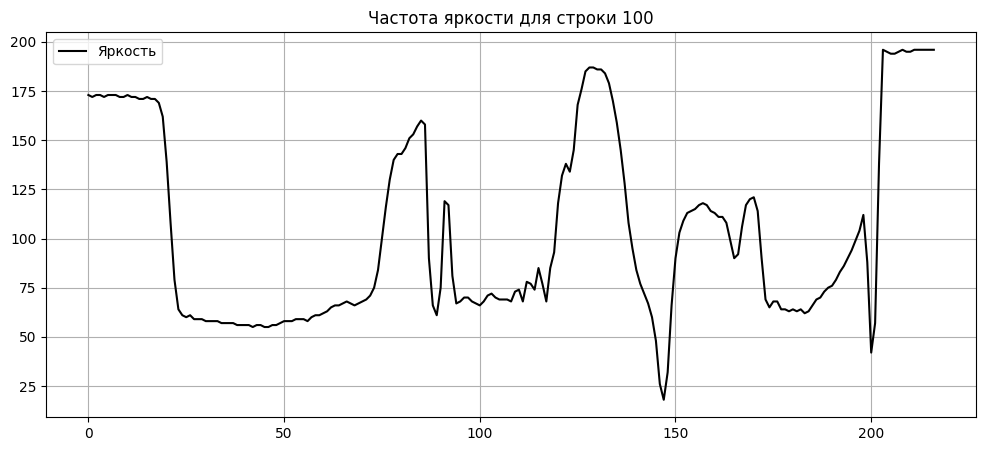

In [117]:
def plot_row_frequencies(color_img, gray_img, row_indices):
    for row_idx in row_indices:
        # цветное изображения
        row_data_color = color_img[row_idx, :, :]
        plt.figure(figsize=(12, 5))
        plt.plot(row_data_color[:, 0], color='red', label='R')
        plt.plot(row_data_color[:, 1], color='green', label='G')
        plt.plot(row_data_color[:, 2], color='blue', label='B')
        plt.title(f'Частота каналов для строки {row_idx}')
        plt.legend()
        plt.grid(True)

        # серое изображения
        row_data_gray = gray_img[row_idx, :]
        plt.figure(figsize=(12, 5))
        plt.plot(row_data_gray, color='black', label='Яркость')
        plt.title(f'Частота яркости для строки {row_idx}')
        plt.legend()
        plt.grid(True)

plot_row_frequencies(image, gray_image, [50, 100])

# Реализация свертки и фильтров

In [118]:
def get_padding_method(image_channel, pad_h, pad_w):
    image_h, image_w = image_channel.shape
    padded_image = np.zeros((image_h + 2 * pad_h, image_w + 2 * pad_w), dtype=image_channel.dtype)

    padded_image[pad_h:pad_h + image_h, pad_w:pad_w + image_w] = image_channel
    for i in range(pad_h):
        padded_image[i, pad_w:pad_w + image_w] = image_channel[0, :]
        padded_image[image_h + pad_h + i, pad_w:pad_w + image_w] = image_channel[-1, :]
    for j in range(pad_w):
        padded_image[:, j] = padded_image[:, pad_w]
        padded_image[:, image_w + pad_w + j] = padded_image[:, image_w + pad_w - 1]
    return padded_image

In [119]:
def apply_convolution(image_channel, kernel):
    image_h, image_w = image_channel.shape
    kernel_h, kernel_w = kernel.shape
    pad_h = kernel_h // 2
    pad_w = kernel_w // 2

    padded_image = get_padding_method(image_channel, pad_h, pad_w)
    output_image = np.zeros_like(image_channel, dtype=np.float32)

    for i in range(image_h):
        for j in range(image_w):
            window = padded_image[i:i + kernel_h, j:j + kernel_w]
            output_image[i, j] = np.sum(window * kernel)

    return np.clip(output_image, 0, 255).astype(np.uint8)


### Ядра

In [162]:
box_blur_kernel_3x3 = np.ones((3, 3), dtype=np.float32) / 9

sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobel_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
], dtype=np.float32)

gaussian_kernel_3x3 = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.float32) / 16

### Пороговая фильтрация

In [121]:
def threshold_filter(image_channel, threshold_value):
    return (image_channel > threshold_value).astype(np.uint8) * 255

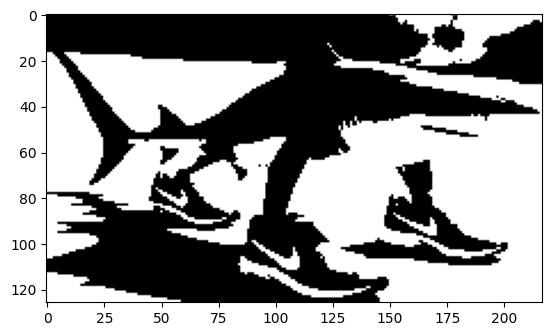

In [122]:
thresholded_image = threshold_filter(gray_image, 100)
plt.imshow(thresholded_image, cmap='gray')

### Медианный фильтр

In [123]:
def median_filter(image_channel, kernel_size):
    image_h, image_w = image_channel.shape
    pad = kernel_size // 2
    padded_image = np.pad(image_channel, pad, mode='edge')
    output_image = np.zeros_like(image_channel, dtype=np.uint8)

    for i in range(image_h):
        for j in range(image_w):
            window = padded_image[i:i + kernel_size, j:j + kernel_size]
            output_image[i, j] = np.median(window)
    return output_image

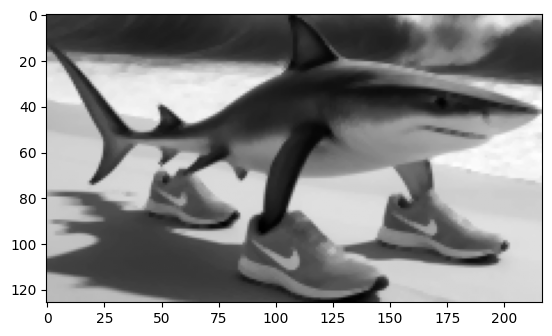

In [124]:
median_filtered_image = median_filter(gray_image, 3)
plt.imshow(median_filtered_image, cmap='gray')

### Применение Box Blur

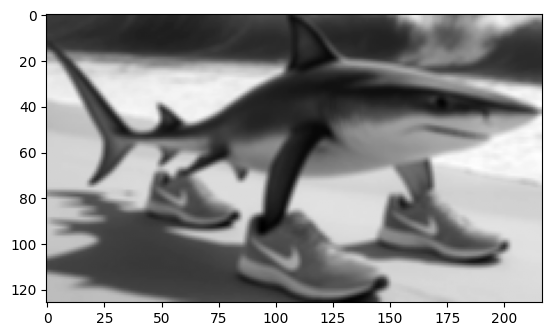

In [125]:
blurred_image_box = apply_convolution(gray_image, box_blur_kernel_3x3)
plt.imshow(blurred_image_box, cmap='gray')

### Применение ядра Гаусса

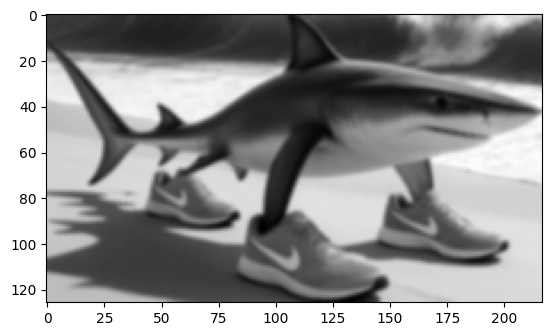

In [163]:
blurred_image_gaussian = apply_convolution(gray_image, gaussian_kernel_3x3)
plt.imshow(blurred_image_gaussian, cmap='gray')

### Применение ядра Собеля

In [127]:
sobel_x_edges = apply_convolution(gray_image, sobel_x)
sobel_y_edges = apply_convolution(gray_image, sobel_y)
sobel_combined_edges = np.sqrt(sobel_x_edges.astype(np.float32)**2 + sobel_y_edges.astype(np.float32)**2)
sobel_combined_edges = np.clip(sobel_combined_edges, 0, 255).astype(np.uint8)

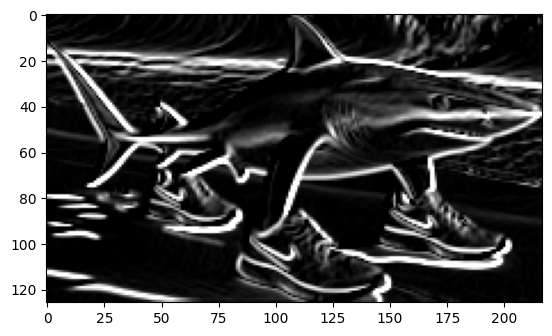

In [128]:
plt.imshow(sobel_combined_edges, cmap='gray')

# Увеличение изображения

In [129]:
def compute_fourier_coefficients_manual(image_channel, m_max, n_max):
    l1, l2 = image_channel.shape[1], image_channel.shape[0]
    
    ajk_coefficients = np.zeros((m_max + 1, n_max + 1), dtype=np.float32)

    total_j_iterations = m_max + 1

    for j in tqdm(range(total_j_iterations), desc="Вычисление a_jk"):
        for k in range(n_max + 1):
            sum_val = 0.0
            for x_idx in range(l1): 
                for y_idx in range(l2): 
                    f_xy = image_channel[y_idx, x_idx]

                    cos_arg_x = j * np.pi * x_idx / l1
                    cos_arg_y = k * np.pi * y_idx / l2
                    
                    sum_val += f_xy * np.cos(cos_arg_x) * np.cos(cos_arg_y)
            
            ajk_coefficients[j, k] = sum_val / (l1 * l2)
        
    return ajk_coefficients

In [134]:
def reconstruct_and_upscale_fourier_series(ajk_coefficients, original_dimensions, target_height, target_width):
    m_max, n_max = ajk_coefficients.shape[0] - 1, ajk_coefficients.shape[1] - 1
    original_height, original_width = original_dimensions[0], original_dimensions[1]

    upscaled_image = np.zeros((target_height, target_width), dtype=np.float32)

    for y_prime in tqdm(range(target_height), desc="Восстановление изображения"): 
        for x_prime in range(target_width): 
            sum_val = 0.0

            x_scaled = x_prime * original_width / target_width
            y_scaled = y_prime * original_height / target_height

            for j in range(m_max + 1):
                for k in range(n_max + 1):
                    ajk = ajk_coefficients[j, k] 
                    
                    cos_arg_x = j * np.pi * x_scaled / original_width
                    cos_arg_y = k * np.pi * y_scaled / original_height
                    
                    sum_val += ajk * np.cos(cos_arg_x) * np.cos(cos_arg_y)
            
            upscaled_image[y_prime, x_prime] = sum_val
        
    return np.clip(upscaled_image, 0, 255).astype(np.uint8)

### Коэффициент увеличения

In [143]:
new_height = int(gray_image.shape[0] * 2)
new_width = int(gray_image.shape[1] * 2)

### Вычислене коэффициентов

In [148]:
ajk_coeffs = compute_fourier_coefficients_manual(gray_image, 100, 100)

Вычисление a_jk: 100%|██████████| 101/101 [26:46<00:00, 15.91s/it]


### Восстановление и увеличение изображения

In [149]:
upscaled_image_fourier_series = reconstruct_and_upscale_fourier_series(
    ajk_coeffs, gray_image.shape, new_height, new_width)

Восстановление изображения:   0%|          | 0/252 [00:00<?, ?it/s]

Восстановление изображения:  12%|█▏        | 30/252 [08:42<1:04:23, 17.40s/it]


KeyboardInterrupt: 

Text(0.5, 1.0, 'Оригинальное серое изображение (126x217)')

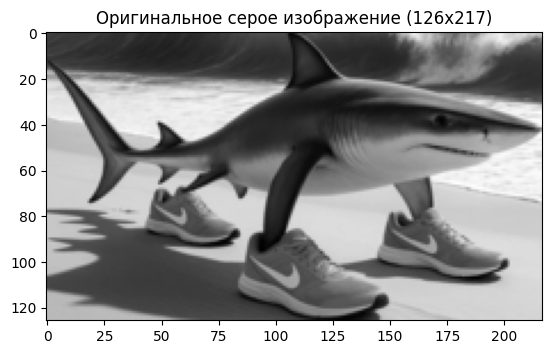

In [ ]:
plt.imshow(gray_image, cmap='gray')
plt.title(f'Оригинальное серое изображение ({gray_image.shape[0]}x{gray_image.shape[1]})')

Text(0.5, 1.0, 'Увеличенное изобажение (252x434)')

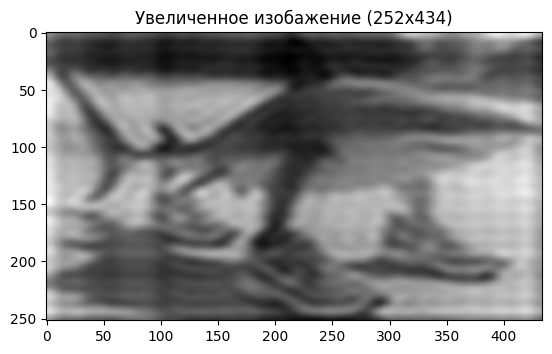

In [ ]:
plt.imshow(upscaled_image_fourier_series, cmap='gray')
plt.title(f'Увеличенное изобажение ({new_height}x{new_width})')

# Фурье-Спектр и частотная Фильтрация

In [156]:
def display_fourier_spectrum(image_channel):
    f = np.fft.fft2(image_channel)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-10)

    plt.imshow(magnitude_spectrum, cmap='gray')
    plt.title('Фурье-спектр изображения')
    plt.colorbar()

In [157]:
def apply_fourier_filter(image_channel, filter_type='low_pass', cutoff_frequency=30):
    f = np.fft.fft2(image_channel)
    fshift = np.fft.fftshift(f)

    rows, cols = image_channel.shape
    crow, ccol = rows // 2, cols // 2

    mask = np.zeros((rows, cols), dtype=np.uint8)
    for i in range(rows):
        for j in range(cols):
            distance = np.sqrt((i - crow)**2 + (j - ccol)**2)
            if filter_type == 'low_pass':
                if distance <= cutoff_frequency:
                    mask[i, j] = 1
            elif filter_type == 'high_pass':
                if distance > cutoff_frequency:
                    mask[i, j] = 1

    fshift_filtered = fshift * mask
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)

    return np.clip(img_back, 0, 255).astype(np.uint8)


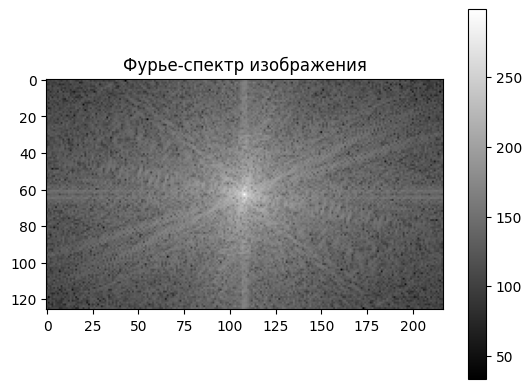

In [158]:
display_fourier_spectrum(gray_image)

### Низкочастотная фильтрация

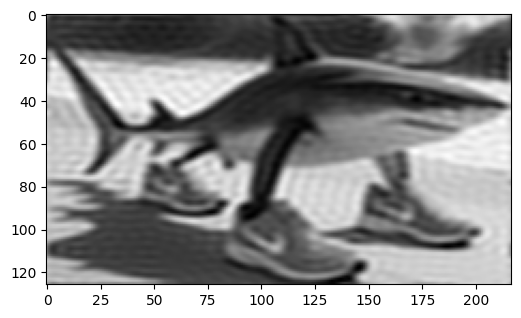

In [159]:
low_pass_filtered_fourier = apply_fourier_filter(gray_image, 'low_pass', cutoff_frequency=30)
plt.figure(figsize=(6, 6))
plt.imshow(low_pass_filtered_fourier, cmap='gray')

### Высокочастотная фильтрация

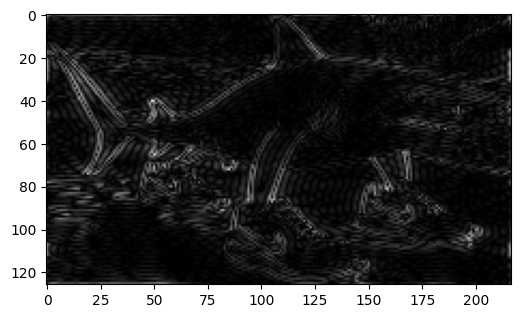

In [160]:
high_pass_filtered_fourier = apply_fourier_filter(gray_image, 'high_pass', cutoff_frequency=30)
plt.figure(figsize=(6, 6))
plt.imshow(high_pass_filtered_fourier, cmap='gray')

# Повышение резкости изображения

In [161]:
def unsharp_masking(original_image_channel, blurred_image_channel, amount=1.0):
    sharpness_mask = original_image_channel.astype(np.float32) - blurred_image_channel.astype(np.float32)
    sharpened_image = original_image_channel.astype(np.float32) + amount * sharpness_mask
    return np.clip(sharpened_image, 0, 255).astype(np.uint8)

### Используем Гауссов фильтр для получения низкочастотной версии

In [165]:
blurred_for_unsharp = apply_convolution(gray_image, gaussian_kernel_3x3)

In [166]:
sharpened_final_image = unsharp_masking(gray_image, blurred_for_unsharp, amount=1.5)

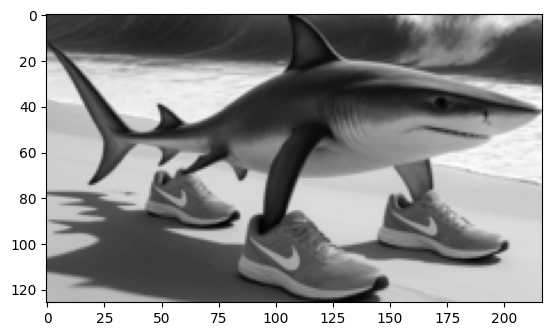

In [167]:
plt.imshow(gray_image, cmap='gray')

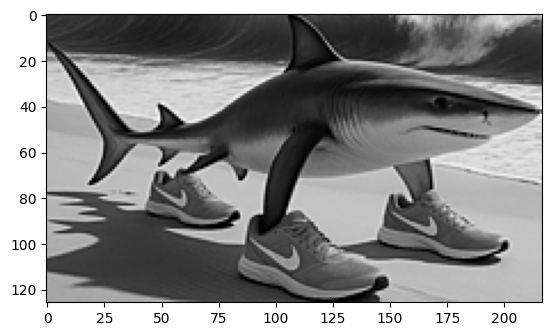

In [168]:
plt.imshow(sharpened_final_image, cmap='gray')